# Explainable Hybrid Machine Learning Framework for Predictive Maintenance

## Project Objective

The objective of this project is to develop an explainable machine learning framework
for predicting machine failures using sensor and operational data.

The project compares multiple machine learning models and combines strong tree-based
models into a hybrid prediction framework. Explainability techniques are then used
to identify the features that contribute most to machine failure predictions.

### Key Steps
1. Dataset description
2. Data preprocessing
3. Exploratory data analysis
4. Feature engineering and selection
5. Model building
6. Hyperparameter tuning
7. Model evaluation
8. Model comparison
9. Explainability using SHAP
10. Final prediction demonstration

In [1]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

import random

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


# Dataset Source

The dataset used in this project is the AI4I 2020 Predictive Maintenance Dataset.

# Source:

https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset


In [2]:
# Load the AI4I 2020 Predictive Maintenance Dataset


DATA_PATH = "../data/ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# 1. Dataset Description

### Dataset
AI4I 2020 Predictive Maintenance Dataset

### Objective
The target variable is `Machine failure`, which indicates whether a machine
experienced a failure.

The dataset contains sensor measurements and machine operating conditions such
as air temperature, process temperature, rotational speed, torque and tool wear.

Identifier columns such as UDI and Product ID are not used as predictive features.

In [3]:
# Dataset description

print("Number of records:", df.shape[0])
print("Number of features:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nTarget distribution:")
display(df["Machine failure"].value_counts())

print("\nTarget distribution (%):")
display(
    df["Machine failure"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .to_frame("Percentage")
)

Number of records: 10000
Number of features: 14

Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Data types:


,Data Type
UDI,int64
Product ID,str
Type,str
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64



Target distribution:


Machine failure
0    9661
1     339
Name: count, dtype: int64


Target distribution (%):


,Percentage
Machine failure,
0,96.61
1,3.39


# 2. Data Preprocessing

The dataset is checked for missing values and duplicate records.
Identifier columns are removed, the target variable is separated,
and appropriate preprocessing pipelines are created for numerical
and categorical features.

The preprocessing pipeline includes:
- Missing-value imputation
- Categorical encoding
- Feature scaling
- Train-test splitting
- Leakage prevention

In [4]:
# Check missing values and duplicates

print("Missing values:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nNumber of duplicate rows:", df.duplicated().sum())

# Remove duplicate records
df = df.drop_duplicates().reset_index(drop=True)

print("\nShape after duplicate removal:", df.shape)

Missing values:


,Missing Values
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0



Number of duplicate rows: 0

Shape after duplicate removal: (10000, 14)


In [5]:
# Define target and remove identifier columns

TARGET = "Machine failure"

ID_COLUMNS = ["UDI", "Product ID"]

# Remove identifier columns if they exist
df_model = df.drop(columns=[c for c in ID_COLUMNS if c in df.columns]).copy()

print("Model dataset shape:", df_model.shape)

# Separate input features and target
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget:", TARGET)

Model dataset shape: (10000, 12)

Feature columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Target: Machine failure


In [6]:
# Identify numerical and categorical columns

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

# Preprocessing pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("\nPreprocessing pipeline created.")

Numerical features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Categorical features:
['Type']

Preprocessing pipeline created.


# 3. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand:

- Dataset statistics
- Target/class distribution
- Feature distributions
- Relationships between numerical variables
- Correlation between features

The observations from EDA will be used to guide feature engineering and model selection.

In [7]:
# Descriptive statistics

display(df_model.describe().T)

,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.0,0.0,0.0,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.0,0.0,0.0,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.0,0.0,0.0,1.0
OSF,10000.0,0.00980,0.098514,0.0,0.0,0.0,0.0,1.0


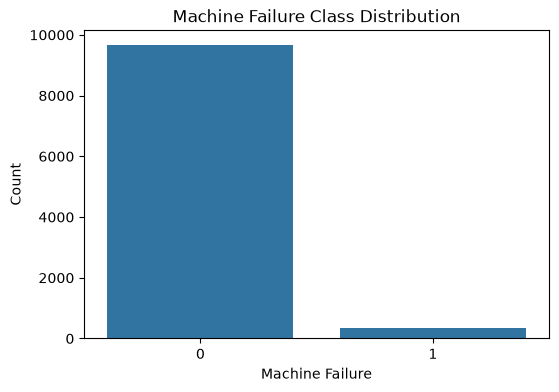

In [8]:
# Target class distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df_model,
    x=TARGET
)

plt.title("Machine Failure Class Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.show()

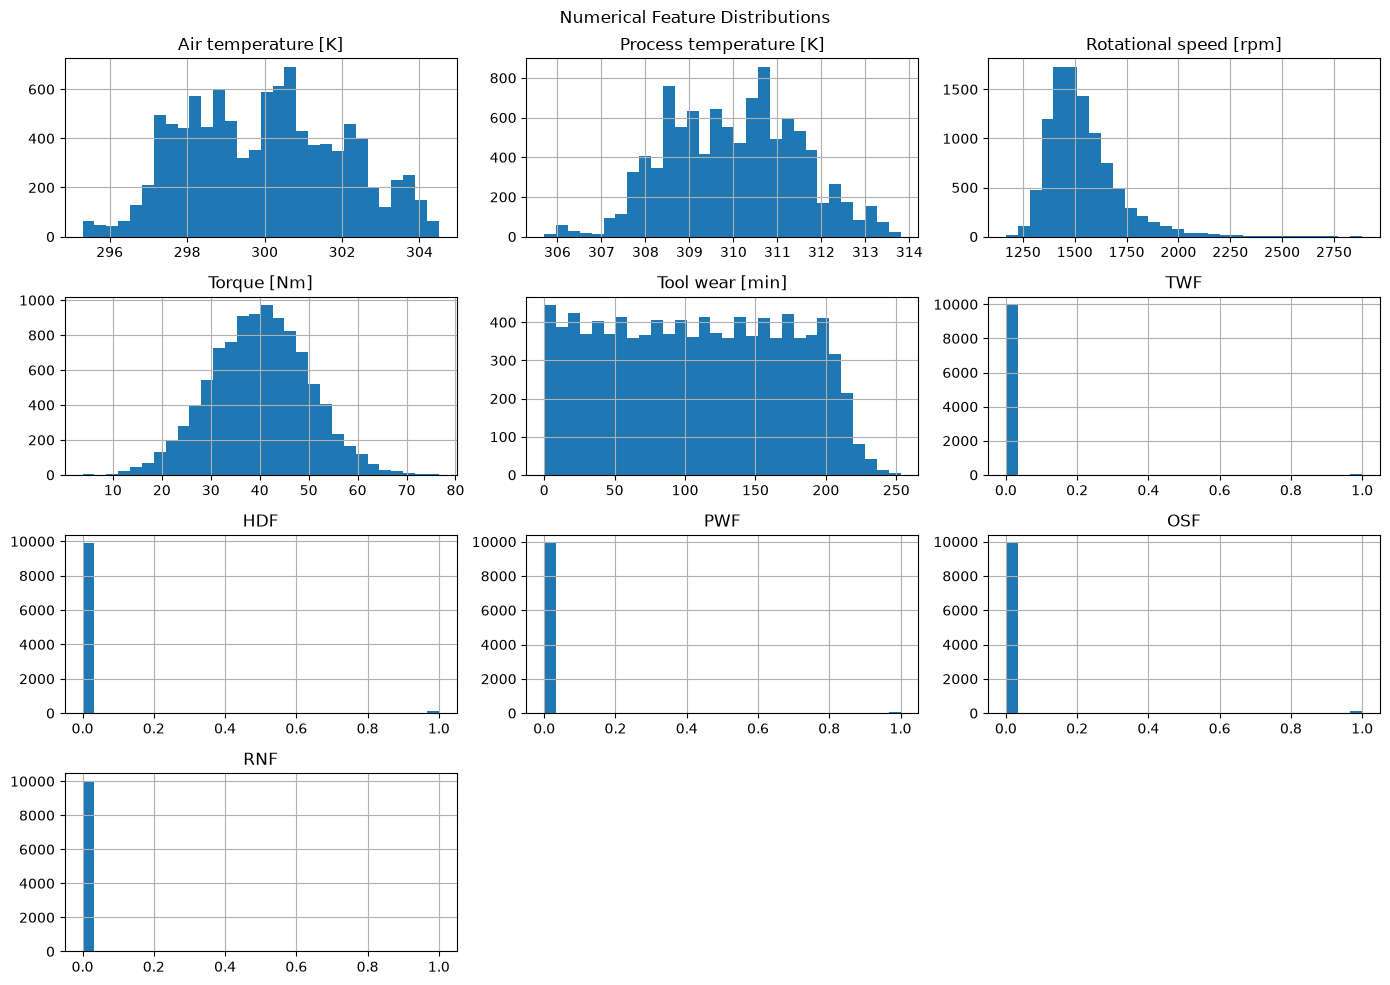

In [9]:
# Numerical feature distributions

df_model[numeric_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

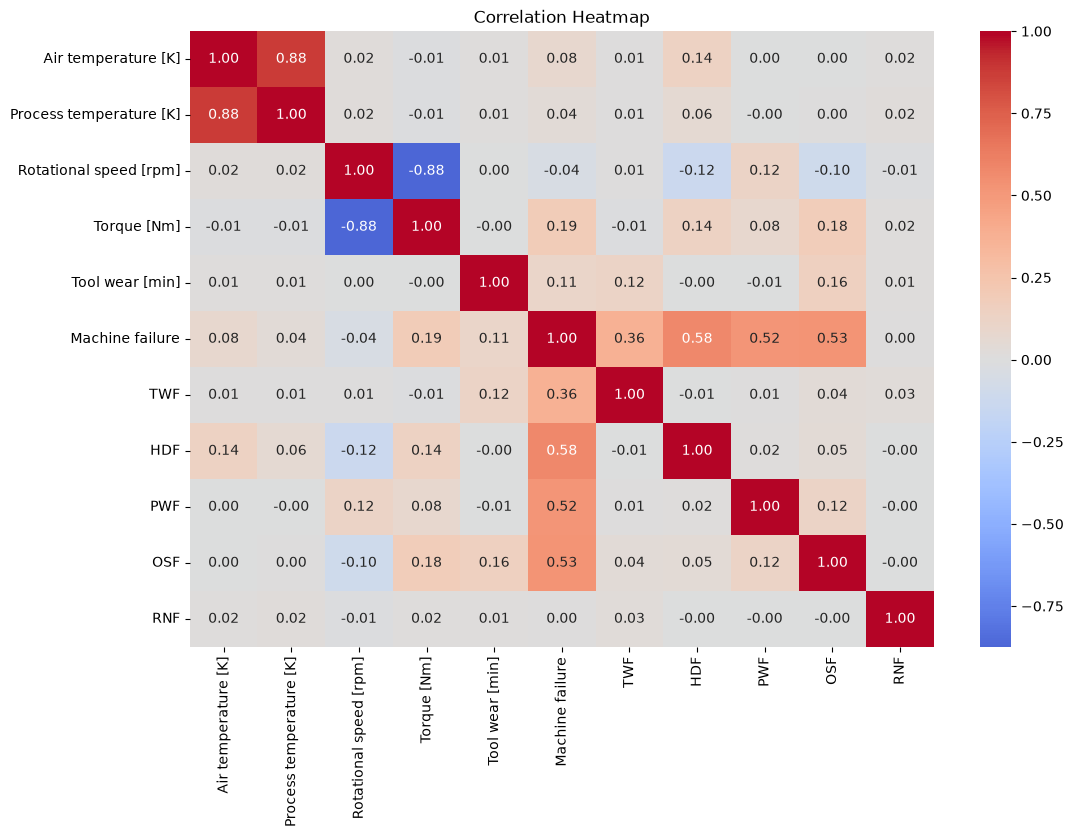


EDA Observation:
The correlation matrix helps identify relationships between numerical variables.
Highly correlated variables and operational measurements can provide useful
information for predictive maintenance.



In [10]:
# Correlation heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df_model.select_dtypes(
    include=["int64", "float64"]
).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

print("""
EDA Observation:
The correlation matrix helps identify relationships between numerical variables.
Highly correlated variables and operational measurements can provide useful
information for predictive maintenance.
""")

# 4. Feature Engineering and Selection

Two domain-inspired features are created:

### 1. Temperature Difference
Temperature Difference = Process Temperature − Air Temperature

This represents the difference between the machine's process environment and
the surrounding air temperature.

### 2. Mechanical Power Proxy
Mechanical Power Proxy = Rotational Speed × Torque

This provides a simple proxy for the mechanical operating load.

Identifier variables such as UDI and Product ID are excluded because they identify
records/products rather than representing machine operating behavior.

In [11]:
# Feature engineering

X_engineered = X.copy()

X_engineered["Temperature Difference [K]"] = (
    X_engineered["Process temperature [K]"]
    - X_engineered["Air temperature [K]"]
)

X_engineered["Mechanical Power Proxy"] = (
    X_engineered["Rotational speed [rpm]"]
    * X_engineered["Torque [Nm]"]
)

print("New features created:")
print([
    "Temperature Difference [K]",
    "Mechanical Power Proxy"
])

display(X_engineered.head())

New features created:
['Temperature Difference [K]', 'Mechanical Power Proxy']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Temperature Difference [K],Mechanical Power Proxy
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,10.5,66382.8
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,10.5,65190.4
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,10.4,74001.2
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,10.4,56603.5
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,10.5,56320.0


In [12]:
# Redefine feature lists after feature engineering

X = X_engineered.copy()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Recreate preprocessing pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Re-split using engineered features
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Final feature count:", X.shape[1])
print("\nFinal feature list:")
for feature in X.columns:
    print("-", feature)

Final feature count: 13

Final feature list:
- Type
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- TWF
- HDF
- PWF
- OSF
- RNF
- Temperature Difference [K]
- Mechanical Power Proxy


In [13]:
# Train-test split
# The test set remains isolated from model selection and tuning.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

print("\nLeakage prevention:")
print("Preprocessing will be fitted only on training data through sklearn pipelines.")

Training shape: (8000, 13)
Testing shape : (2000, 13)

Training target distribution:
Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Testing target distribution:
Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64

Leakage prevention:
Preprocessing will be fitted only on training data through sklearn pipelines.


# 5. Model Building

The following supervised classification models are developed:

1. Logistic Regression — linear baseline
2. Decision Tree — interpretable tree model
3. Random Forest — ensemble of decision trees
4. XGBoost — gradient-boosted tree model
5. Hybrid Model — combines Random Forest and XGBoost probabilities

The tree-based models are particularly relevant to the course syllabus, which covers
decision trees, Random Forests, boosting, XGBoost, feature importance and explainability.

In [14]:
# Import XGBoost

try:
    from xgboost import XGBClassifier
    xgb_available = True
    print("XGBoost is available.")
except ImportError:
    xgb_available = False
    print("XGBoost is not installed.")
    print("Install it using: pip install xgboost")

XGBoost is available.


In [15]:
# Create models

models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=8,
            min_samples_split=10,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_split=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

if xgb_available:
    models["XGBoost"] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=RANDOM_STATE
        ))
    ])

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost


In [16]:
# Train all models

trained_models = {}
model_results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    }

    model_results.append(result)
    trained_models[name] = model

results_df = pd.DataFrame(model_results)

display(
    results_df.sort_values(
        "F1 Score",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9990,1.000000,0.970588,0.985075,0.972468,0.971648
1,Random Forest,0.9990,1.000000,0.970588,0.985075,0.989306,0.973740
2,XGBoost,0.9990,1.000000,0.970588,0.985075,0.996072,0.978292
3,Decision Tree,0.9885,0.758621,0.970588,0.851613,0.985134,0.971588


In [17]:
# Stratified K-Fold cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Mean CV F1": scores.mean(),
        "Std CV F1": scores.std()
    })

cv_df = pd.DataFrame(cv_results)

display(cv_df.sort_values(
    "Mean CV F1",
    ascending=False
).reset_index(drop=True))

,Model,Mean CV F1,Std CV F1
0,Logistic Regression,0.986844,0.009680
1,XGBoost,0.984940,0.011341
2,Random Forest,0.983000,0.013929
3,Decision Tree,0.901892,0.034390


# 6. Hyperparameter Tuning

RandomizedSearchCV is used to tune the Random Forest model.

The parameters considered include:

- Number of trees
- Maximum tree depth
- Minimum samples required for splitting
- Minimum samples required at a leaf

Randomized search reduces the amount of computation compared with exhaustively
testing every possible parameter combination.

In [18]:
# Random Forest hyperparameter tuning

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_distributions = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [6, 8, 10, 12, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=15,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print("Best parameters:")
print(random_search.best_params_)

print("\nBest cross-validation F1:")
print(round(random_search.best_score_, 4))

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 12}

Best cross-validation F1:
0.9849


In [19]:
# Compare tuned Random Forest with original Random Forest

tuned_pred = best_rf.predict(X_test)
tuned_prob = best_rf.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred, zero_division=0),
    "Recall": recall_score(y_test, tuned_pred, zero_division=0),
    "F1 Score": f1_score(y_test, tuned_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, tuned_prob),
    "PR-AUC": average_precision_score(y_test, tuned_prob)
}

before_tuning = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0].to_dict()

before_after = pd.DataFrame([
    before_tuning,
    tuned_metrics
])

display(before_after)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Random Forest,0.999,1.0,0.970588,0.985075,0.989306,0.973740
1,Tuned Random Forest,0.999,1.0,0.970588,0.985075,0.991756,0.977729


Classification Report - Tuned Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



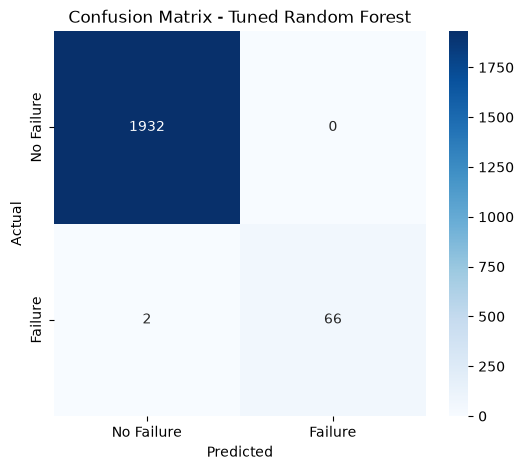

In [20]:
# Classification Report and Confusion Matrix

print("Classification Report - Tuned Random Forest")
print(classification_report(
    y_test,
    tuned_pred,
    zero_division=0
))

cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

# 7. Model Evaluation

The trained models are evaluated using classification metrics suitable
for predictive maintenance.

The evaluation includes:
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC
- Classification Report
- Confusion Matrix
- ROC Curve

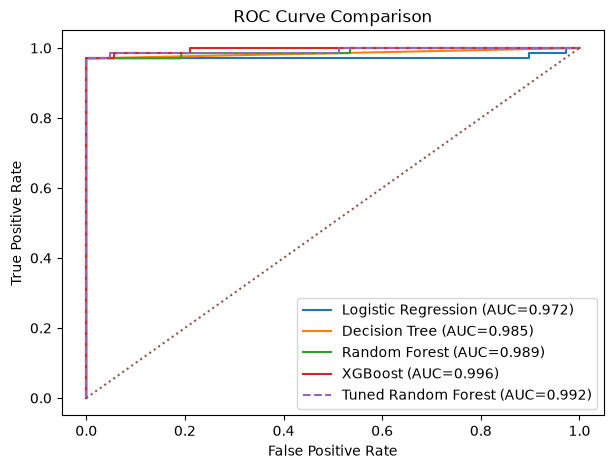

In [21]:
# ROC Curve and Precision-Recall Curve

plt.figure(figsize=(7, 5))

for name, model in trained_models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )

# Add tuned Random Forest
fpr, tpr, _ = roc_curve(y_test, tuned_prob)

plt.plot(
    fpr,
    tpr,
    linestyle="--",
    label=f"Tuned Random Forest (AUC={roc_auc_score(y_test, tuned_prob):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle=":")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [22]:
# Create Hybrid Random Forest + XGBoost model

if "XGBoost" in trained_models:

    rf_model = best_rf
    xgb_model = trained_models["XGBoost"]

    rf_prob = rf_model.predict_proba(X_test)[:, 1]
    xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

    # Equal-weight probability averaging
    hybrid_prob = (rf_prob + xgb_prob) / 2

    hybrid_pred = (hybrid_prob >= 0.5).astype(int)

    hybrid_metrics = {
        "Model": "Hybrid RF + XGBoost",
        "Accuracy": accuracy_score(y_test, hybrid_pred),
        "Precision": precision_score(y_test, hybrid_pred, zero_division=0),
        "Recall": recall_score(y_test, hybrid_pred, zero_division=0),
        "F1 Score": f1_score(y_test, hybrid_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, hybrid_prob),
        "PR-AUC": average_precision_score(y_test, hybrid_prob)
    }

    final_comparison = pd.concat(
        [
            results_df,
            pd.DataFrame([tuned_metrics]),
            pd.DataFrame([hybrid_metrics])
        ],
        ignore_index=True
    )

else:

    print("XGBoost is not available, so the hybrid model cannot be created.")

    final_comparison = pd.concat(
        [
            results_df,
            pd.DataFrame([tuned_metrics])
        ],
        ignore_index=True
    )

display(
    final_comparison.sort_values(
        "F1 Score",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9990,1.000000,0.970588,0.985075,0.972468,0.971648
1,Random Forest,0.9990,1.000000,0.970588,0.985075,0.989306,0.973740
2,Tuned Random Forest,0.9990,1.000000,0.970588,0.985075,0.991756,0.977729
3,XGBoost,0.9990,1.000000,0.970588,0.985075,0.996072,0.978292
4,Hybrid RF + XGBoost,0.9990,1.000000,0.970588,0.985075,0.992228,0.977676
5,Decision Tree,0.9885,0.758621,0.970588,0.851613,0.985134,0.971588


# 8. Model Comparison and Selection

The models are compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC

For predictive maintenance, the evaluation should consider recall and F1-score
along with accuracy because missing an actual machine failure can be important.

The final model is selected based on the evaluation results obtained on the
held-out test set.

The selected model will then be used for explainability and final prediction.

Classification Report - Tuned Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



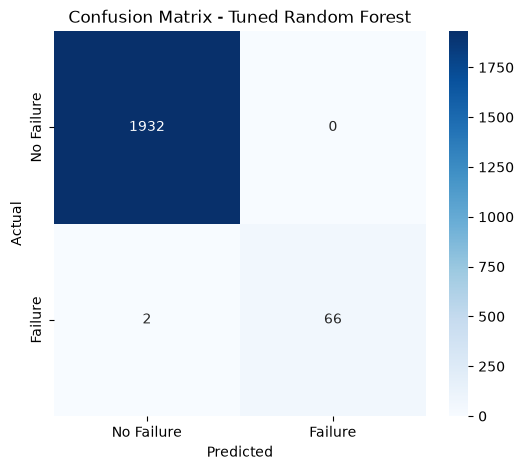

In [23]:
# Classification Report and Confusion Matrix

print("Classification Report - Tuned Random Forest")
print(classification_report(
    y_test,
    tuned_pred,
    zero_division=0
))

cm = confusion_matrix(y_test, tuned_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Failure", "Failure"],
    yticklabels=["No Failure", "Failure"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.show()

SHAP feature importance:


,Feature,Mean Absolute SHAP
8,num__OSF,0.069505
6,num__HDF,0.069126
7,num__PWF,0.068752
2,num__Rotational speed [rpm],0.058997
11,num__Mechanical Power Proxy,0.056299
5,num__TWF,0.053110
3,num__Torque [Nm],0.052959
4,num__Tool wear [min],0.047747
10,num__Temperature Difference [K],0.032267
0,num__Air temperature [K],0.017641


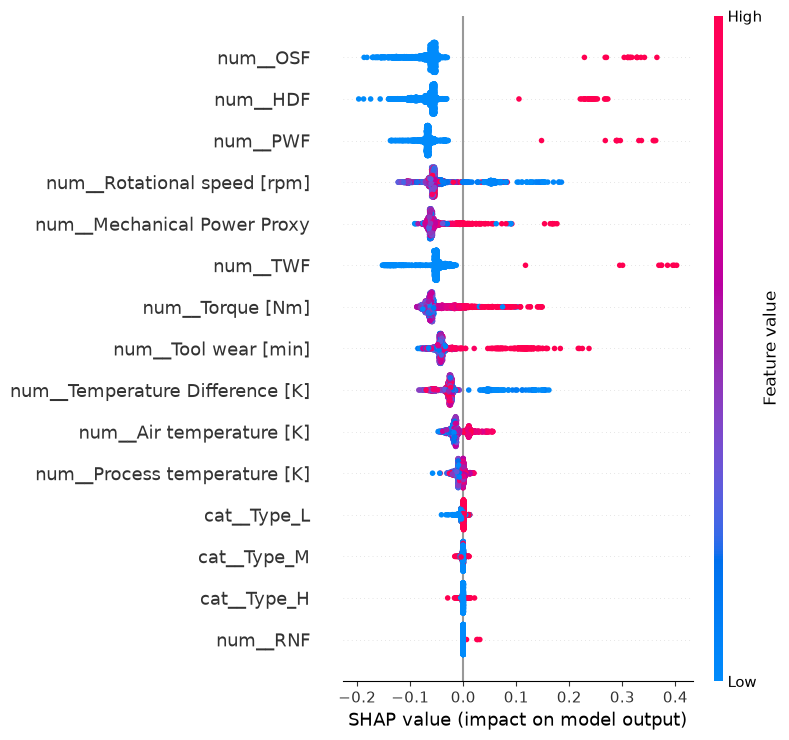


FINAL PREDICTION DEMONSTRATION

Sample input:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF,Temperature Difference [K],Mechanical Power Proxy
2997,L,300.5,309.8,1345,62.7,153,0,0,0,0,0,9.3,84331.5


Predicted Machine Failure: NO
Failure probability: 0.1319

Project workflow completed successfully.


In [25]:
# SHAP Explainability + Final Prediction Demonstration

try:
    import shap

    # Use the final selected model from the notebook workflow.
    final_model = best_rf

    # Transform the held-out data using the fitted preprocessor.
    X_test_processed = final_model.named_steps["preprocessor"].transform(X_test)
    feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

    # Create SHAP TreeExplainer on the underlying Random Forest model.
    rf_estimator = final_model.named_steps["model"]
    explainer = shap.TreeExplainer(rf_estimator)
    shap_values = explainer.shap_values(X_test_processed)

    # Normalize SHAP output across supported SHAP versions.
    if isinstance(shap_values, list):
        shap_for_failure = shap_values[1]
    elif getattr(shap_values, "ndim", 0) == 3:
        shap_for_failure = shap_values[:, :, 1]
    else:
        shap_for_failure = shap_values

    print("SHAP feature importance:")

    shap_importance = pd.DataFrame({
        "Feature": feature_names,
        "Mean Absolute SHAP": np.abs(shap_for_failure).mean(axis=0)
    }).sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )

    display(shap_importance.head(10))

    # SHAP summary plot
    shap.summary_plot(
        shap_for_failure,
        X_test_processed,
        feature_names=feature_names,
        show=True
    )

except ImportError:
    print("SHAP is not installed; SHAP explanations were skipped.")
except Exception as e:
    print(f"SHAP explanation failed: {e}")


# ---------------------------------------------------------
# FINAL PREDICTION DEMONSTRATION
# ---------------------------------------------------------

print("\nFINAL PREDICTION DEMONSTRATION")

sample_input = X_test.iloc[[0]].copy()

sample_prediction = final_model.predict(sample_input)[0]
sample_probability = final_model.predict_proba(sample_input)[0, 1]

print("\nSample input:")
display(sample_input)

print(
    "Predicted Machine Failure:",
    "YES" if sample_prediction == 1 else "NO"
)

print(
    f"Failure probability: {sample_probability:.4f}"
)

print("\nProject workflow completed successfully.")